In [185]:
import pandas as pd
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import joblib

In [186]:
df = pd.read_csv('../data/02_processed/bank_transactions_data_processed.csv')

In [187]:
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,AgeGroup_Encoded,AmountCategory_Encoded
0,-1.076499,-0.782920,0.533564,1.232819,-1.226183,1.426317,-1.340244,-0.550806,-0.204927,-0.002100,-0.695733,0.182405,-0.877862
1,0.374414,-0.089092,0.533564,-0.488098,-1.226183,1.313735,-1.340244,0.308078,-0.204927,2.227746,0.139512,0.182405,1.139131
2,-0.626982,0.027940,0.533564,0.167490,1.260877,-1.444512,1.306141,-0.908674,-0.204927,-1.031021,-1.310167,1.349893,-0.877862
3,-0.393770,-0.590654,0.533564,0.986973,1.260877,-1.050477,1.306141,-1.352431,-0.204927,0.889367,-0.138903,1.349893,-0.877862
4,-1.079063,0.971156,-1.874190,-1.635375,1.260877,0.019048,1.306141,1.124017,-0.204927,0.595467,-1.550180,-0.985082,-0.877862


In [188]:
df.describe()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,AgeGroup_Encoded,AmountCategory_Encoded
count,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03,2.509000e+03
mean,-3.823167e-17,2.371780e-17,-1.624846e-16,-1.543427e-16,-1.302709e-16,-8.637526e-17,2.513379e-17,-2.265581e-17,1.784145e-16,-2.902775e-17,9.487119e-17,3.539970e-17,6.088748e-17
std,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00,1.000199e+00
min,-1.131907e+00,-1.730316e+00,-1.874190e+00,-1.717323e+00,-1.226183e+00,-1.500803e+00,-1.340244e+00,-1.567152e+00,-2.049266e-01,-1.294347e+00,-1.934201e+00,-9.850824e-01,-8.778623e-01
25%,-8.017407e-01,-8.637275e-01,5.335637e-01,-8.158911e-01,-1.226183e+00,-9.941861e-01,-1.340244e+00,-8.084713e-01,-2.049266e-01,-9.276896e-01,-8.589423e-01,-9.850824e-01,-8.778623e-01
50%,-2.898046e-01,-1.318265e-03,5.335637e-01,3.592795e-03,1.734698e-02,1.904777e-02,4.240123e-01,-1.070495e-01,-2.049266e-01,-9.544356e-02,5.104461e-03,1.824054e-01,-8.778623e-01
75%,5.081072e-01,8.666639e-01,5.335637e-01,8.230766e-01,1.260877e+00,8.071185e-01,1.306141e+00,5.943723e-01,-2.049266e-01,6.507208e-01,8.787518e-01,1.349893e+00,1.139131e+00
max,2.472879e+00,1.730466e+00,5.335637e-01,1.724509e+00,1.260877e+00,1.989225e+00,1.306141e+00,2.584120e+00,6.516131e+00,2.542128e+00,1.742799e+00,1.349893e+00,1.139131e+00


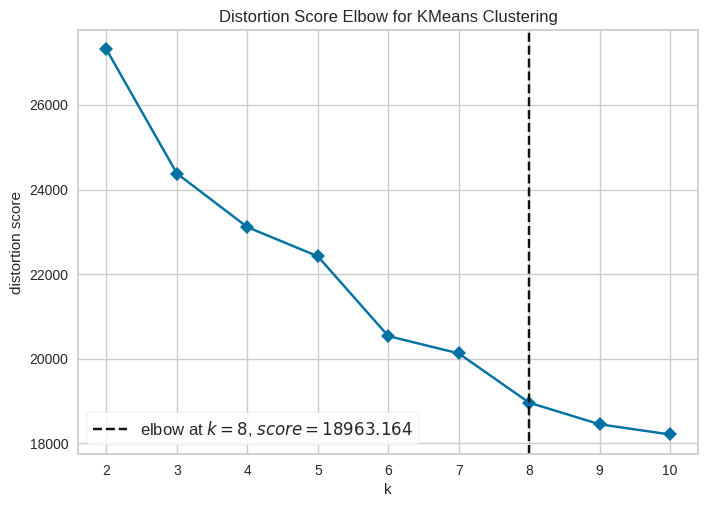

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [189]:
model = KMeans(random_state=42, n_init='auto')

visualizer = KElbowVisualizer(
  model,
  k=(2,11),
  timings=False,
  locate_elbow=True
)

visualizer.fit(df)
n_cluster = visualizer.elbow_value_

visualizer.show()

In [190]:
kmeans = KMeans(n_clusters=n_cluster, n_init='auto', random_state=42)

cluster_labels = kmeans.fit_predict(df)

df['Cluster'] = cluster_labels

joblib.dump(kmeans, "../models/kmeans_clustering.h5")

df_no_pca_final = df.copy()
df_no_pca_final.rename(columns={'Cluster': 'Target'}, inplace=True)
df_no_pca_final.to_csv('../reports/tables/clustering.csv', index=False)

In [191]:
silhouette_avg = silhouette_score(df, cluster_labels)
print(f"Nilai Silhouette untuk k={n_cluster} adalah: {silhouette_avg:.4f}")

if silhouette_avg > 0.7:
  print("Interpretasi: Struktur cluster sangat baik dan padat.")
elif silhouette_avg > 0.5:
  print("Interpretasi: Struktur cluster cukup baik dan terpisah dengan wajar.")
elif silhouette_avg > 0.2:
  print("Interpretasi: Struktur cluster lemah atau tumpang tindih.")
else:
  print("Interpretasi: Struktur cluster sangat buruk atau tidak ditemukan.")

Nilai Silhouette untuk k=8 adalah: 0.2028
Interpretasi: Struktur cluster lemah atau tumpang tindih.


In [192]:
aggregations = {
  'TransactionAmount': ['mean', 'median', 'min', 'max'],
  'CustomerAge': ['mean', 'min', 'max'],
  'TransactionDuration': ['mean', 'min', 'max'],
  'LoginAttempts': ['mean', 'max', 'count'],
  'AccountBalance': ['mean', 'median', 'max']
}

cluster_analysis = df.groupby('Cluster').agg(aggregations).round(2)

cluster_analysis.columns = ['_'.join(col).strip() for col in cluster_analysis.columns.values]

cluster_analysis.to_csv('../reports/tables/cluster_analysis.csv', index=False)

cluster_analysis

,TransactionAmount_mean,TransactionAmount_median,TransactionAmount_min,TransactionAmount_max,CustomerAge_mean,CustomerAge_min,CustomerAge_max,TransactionDuration_mean,TransactionDuration_min,TransactionDuration_max,LoginAttempts_mean,LoginAttempts_max,LoginAttempts_count,AccountBalance_mean,AccountBalance_median,AccountBalance_max
Cluster,,,,,,,,,,,,,,,,
0,1.01,0.81,-0.12,2.47,-1.18,-1.50,-0.88,0.00,-1.57,2.50,-0.17,3.16,307,-0.86,-1.03,1.25
1,0.87,0.60,-0.13,2.47,0.47,-1.05,1.99,-0.01,-1.57,2.58,-0.18,1.48,580,0.29,0.28,2.54
2,-0.71,-0.74,-1.13,0.03,0.08,-0.99,1.43,0.07,-1.57,2.58,-0.18,1.48,252,1.36,1.25,2.53
3,-0.69,-0.74,-1.13,-0.13,-1.21,-1.50,-0.88,-0.02,-1.54,2.57,-0.15,3.16,380,-0.86,-1.03,1.19
4,-0.69,-0.74,-1.13,-0.14,0.49,-0.99,1.99,-0.32,-1.55,2.41,-0.19,1.48,272,-0.09,-0.05,1.25
5,0.01,-0.27,-1.12,2.47,0.52,-1.05,1.99,-0.07,-1.57,2.48,-0.18,1.48,376,0.36,0.32,2.53
6,-0.72,-0.76,-1.13,-0.08,0.76,-1.05,1.99,0.36,-1.54,2.56,-0.19,1.48,255,-0.16,-0.14,1.98
7,-0.05,-0.31,-1.13,2.47,0.09,-1.50,1.99,0.22,-1.55,2.46,4.95,6.52,87,0.13,-0.00,2.51


### Cluster 0: Transaksi Besar dari Saldo Rendah
- TransactionAmount_mean: 1.01 (Jauh di atas rata-rata)
- AccountBalance_mean: -0.86 (Di bawah rata-rata)
- LoginAttempts_count: 307
- Profil: Cluster ini berisi transaksi dengan nominal yang jauh lebih besar dari biasanya, namun berasal dari akun dengan saldo yang cenderung lebih rendah dari rata-rata.
- Tingkat Kecurigaan: Sedang hingga Tinggi 🟠. Transaksi besar dari akun bersaldo rendah adalah pola yang perlu diwaspadai.

### Cluster 1: Profil "Rata-rata" Terbesar
- TransactionAmount_mean: 0.87 (Di atas rata-rata)
- AccountBalance_mean: 0.29 (Sedikit di atas rata-rata)
- LoginAttempts_count: 580 (Cluster Terbesar)
- Profil: Ini adalah kelompok pengguna yang paling umum. Mereka melakukan transaksi sedikit di atas rata-rata dari akun dengan saldo yang juga sedikit di atas rata-rata.
- Tingkat Kecurigaan: Rendah 🟢. Ini kemungkinan besar adalah profil pengguna aktif yang normal.

### Cluster 2: Si Kaya yang Hemat
- TransactionAmount_mean: -0.71 (Jauh di bawah rata-rata)
- AccountBalance_mean: 1.36 (Jauh di atas rata-rata)
- LoginAttempts_count: 252
- Profil: Cluster ini unik, berisi transaksi bernominal sangat kecil yang berasal dari akun dengan saldo yang sangat tinggi.
- Tingkat Kecurigaan: Rendah 🟢. Ini bisa jadi profil nasabah kaya yang menggunakan akunnya untuk transaksi-transaksi kecil atau nasabah yang sangat berhati-hati.

### Cluster 3, 4, 5, 6: Kelompok Pengguna Normal Lainnya
- Keempat cluster ini memiliki statistik yang sangat mirip dan cenderung dekat dengan rata-rata (nilai antara -0.7 hingga 0.5).
- Profil: Mereka semua tampaknya mewakili variasi dari perilaku transaksi normal dengan nominal dan saldo di bawah atau sedikit di atas rata-rata.
- Tingkat Kecurigaan: Rendah 🟢.

### Cluster 7: Upaya Login Brutal! 🚩
- LoginAttempts_max: 6.52 (EKSTREM, JAUH PALING TINGGI)
- LoginAttempts_mean: 2.46 (JAUH PALING TINGGI)
- LoginAttempts_count: 87 (Cluster Terkecil)
- TransactionAmount_mean: -0.76 (Sangat rendah)
- Profil: Ini adalah cluster yang paling menonjol dan mencurigakan. Meskipun nilai transaksinya kecil, cluster ini dicirikan oleh upaya login yang sangat tinggi. Selain itu, ini adalah cluster dengan anggota paling sedikit, yang seringkali menjadi ciri khas kelompok anomali.
- Tingkat Kecurigaan: SANGAT TINGGI 🔴. Pola ini sangat cocok dengan percobaan brute force atau upaya pengambilalihan akun.

In [193]:
n_pca_components = 5
pca_reducer = PCA(n_components=n_pca_components, random_state=42)

principal_components = pca_reducer.fit_transform(df)

df_pca = pd.DataFrame(
  data=principal_components,
  columns=[f'PCA{i+1}' for i in range(n_pca_components)]
)

kmeans_on_pca = KMeans(n_clusters=n_cluster, n_init='auto', random_state=42)
cluster_labels_pca = kmeans_on_pca.fit_predict(df_pca)

df_pca['Cluster'] = cluster_labels_pca

joblib.dump(pca_reducer, "../models/kmeans_pca_clustering.h5")

df_pca_final_labeled = df_pca.copy()
df_pca_final_labeled.rename(columns={'Cluster': 'Target'}, inplace=True)
df_pca_final_labeled.to_csv('../reports/tables/clustering_pca.csv', index=False)

In [194]:
silhouette_avg_pca = silhouette_score(df_pca, cluster_labels_pca)
print(f"Nilai Silhouette untuk k={n_cluster} adalah: {silhouette_avg_pca:.4f}")

if silhouette_avg_pca > 0.7:
  print("Interpretasi: Struktur cluster sangat baik dan padat.")
elif silhouette_avg_pca > 0.5:
  print("Interpretasi: Struktur cluster cukup baik dan terpisah dengan wajar.")
elif silhouette_avg_pca > 0.2:
  print("Interpretasi: Struktur cluster lemah atau tumpang tindih.")
else:
  print("Interpretasi: Struktur cluster sangat buruk atau tidak ditemukan.")

Nilai Silhouette untuk k=8 adalah: 0.5132
Interpretasi: Struktur cluster cukup baik dan terpisah dengan wajar.


In [195]:
df_analysis_pca = df.copy()
df_analysis_pca['Cluster'] = cluster_labels_pca

aggregations_pca = {
  'TransactionAmount': ['mean', 'median', 'min', 'max'],
  'CustomerAge': ['mean', 'min', 'max'],
  'TransactionDuration': ['mean', 'min', 'max'],
  'LoginAttempts': ['mean', 'max', 'count'],
  'AccountBalance': ['mean', 'median', 'max']
}

cluster_analysis_pca = df.groupby('Cluster').agg(aggregations_pca).round(2)

cluster_analysis_pca.columns = ['_'.join(col).strip() for col in cluster_analysis_pca.columns.values]

cluster_analysis_pca.to_csv('../reports/tables/cluster_analysis_pca.csv', index=False)

cluster_analysis_pca

,TransactionAmount_mean,TransactionAmount_median,TransactionAmount_min,TransactionAmount_max,CustomerAge_mean,CustomerAge_min,CustomerAge_max,TransactionDuration_mean,TransactionDuration_min,TransactionDuration_max,LoginAttempts_mean,LoginAttempts_max,LoginAttempts_count,AccountBalance_mean,AccountBalance_median,AccountBalance_max
Cluster,,,,,,,,,,,,,,,,
0,1.01,0.81,-0.12,2.47,-1.18,-1.50,-0.88,0.00,-1.57,2.50,-0.17,3.16,307,-0.86,-1.03,1.25
1,0.87,0.60,-0.13,2.47,0.47,-1.05,1.99,-0.01,-1.57,2.58,-0.18,1.48,580,0.29,0.28,2.54
2,-0.71,-0.74,-1.13,0.03,0.08,-0.99,1.43,0.07,-1.57,2.58,-0.18,1.48,252,1.36,1.25,2.53
3,-0.69,-0.74,-1.13,-0.13,-1.21,-1.50,-0.88,-0.02,-1.54,2.57,-0.15,3.16,380,-0.86,-1.03,1.19
4,-0.69,-0.74,-1.13,-0.14,0.49,-0.99,1.99,-0.32,-1.55,2.41,-0.19,1.48,272,-0.09,-0.05,1.25
5,0.01,-0.27,-1.12,2.47,0.52,-1.05,1.99,-0.07,-1.57,2.48,-0.18,1.48,376,0.36,0.32,2.53
6,-0.72,-0.76,-1.13,-0.08,0.76,-1.05,1.99,0.36,-1.54,2.56,-0.19,1.48,255,-0.16,-0.14,1.98
7,-0.05,-0.31,-1.13,2.47,0.09,-1.50,1.99,0.22,-1.55,2.46,4.95,6.52,87,0.13,-0.00,2.51


### Cluster 0: Transaksi Besar dari Saldo Rendah
- TransactionAmount_mean: 1.01 (Jauh di atas rata-rata)
- AccountBalance_mean: -0.86 (Di bawah rata-rata)
- LoginAttempts_count: 307
- Profil: Sama seperti pada metode K-Means saja, PCA juga berhasil mengisolasi kelompok transaksi bernilai tinggi dari akun bersaldo relatif rendah.
- Tingkat Kecurigaan: Sedang hingga Tinggi 🟠. Konsistensi temuan ini menguatkan bahwa profil ini memang ada di data.

### Cluster 1 & 5: Profil "Rata-rata"
- Cluster 1 (count: 580) dan Cluster 5 (count: 376) keduanya menunjukkan nilai yang sangat dekat dengan rata-rata di hampir semua fitur.
- Profil: Ini adalah kelompok-kelompok besar yang mewakili perilaku pengguna normal atau rata-rata.
- Tingkat Kecurigaan: Rendah 🟢.

### Cluster 2: Si Kaya yang Hemat
- TransactionAmount_mean: -0.71 (Jauh di bawah rata-rata)
- AccountBalance_mean: 1.36 (Jauh di atas rata-rata)
- LoginAttempts_count: 252
- Profil: PCA juga secara konsisten menemukan kelompok nasabah dengan saldo sangat tinggi yang cenderung melakukan transaksi bernilai kecil.
- Tingkat Kecurigaan: Rendah 🟢.

### Cluster 3, 4, 6: Variasi Pengguna Normal
- Seperti pada metode sebelumnya, cluster-cluster ini menunjukkan variasi perilaku normal dengan nilai transaksi dan saldo yang berada di bawah rata-rata. Mereka tidak menunjukkan pola yang menonjol.
- Tingkat Kecurigaan: Rendah 🟢.

### Cluster 7: Upaya Login Brutal (Semakin Jelas!) 🚩
- LoginAttempts_max: 6.52 (Sangat Ekstrem)
- LoginAttempts_mean: 2.46 (Sangat Tinggi)
- LoginAttempts_count: 87 (Cluster Terkecil)
- Profil: Yang paling penting, PCA tidak hanya mempertahankan cluster anomali ini, tetapi mungkin juga membuatnya lebih terdefinisi (seperti yang ditunjukkan oleh peningkatan Silhouette Score). Ini adalah kelompok kecil dengan perilaku login yang sangat mencurigakan.
- Tingkat Kecurigaan: SANGAT TINGGI 🔴.